# LambdaMART on MSLR
### Learning to Rank — Lambda Gradient Approach with GBDT
---
**Dataset**: MSLR 10k  
**Model**: LambdaMART with Optimal Line Search  
**Gradients**: Lambda(λ)  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **LambdaMART**. It uses the exact same $\lambda$-gradients as LambdaRank, but instead of using a neural network, it trains **Gradient Boosted Decision Trees (GBDT)**.

This notebook uses the **Optimal Line Search** for finding the tree weights ($\alpha$). We use a path-following algorithm that directly maximizes NDCG by finding exactly where the rank order of documents swaps.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | How LambdaMART and Optimal Line Search works |
| 5    | Model definition using `ltr.lambdamart.LambdaMART` |
| 6    | Training on Fold 1 |
| 7    | Optimizing the tree complexity |


## Step 1 · Colab Setup & Package Installation

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/Pairwise Approaches", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Pairwise Approaches")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

## Downloading the dataset

In [2]:
import gdown
drive_url = "https://drive.google.com/file/d/105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY/view?usp=drive_link"
# Download the file
gdown.download(drive_url, output="mslr.zip", fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY
From (redirected): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY&confirm=t&uuid=6e5bd0c6-a87b-4eef-9e85-5a7b1c5d9204
To: /content/mslr.zip
100%|██████████| 1.45G/1.45G [00:18<00:00, 79.1MB/s]


'mslr.zip'

## Extraction

In [3]:
# ── Extract MSLR 10k dataset ────────────────────────────────────────────────────
import zipfile, os

ZIP_PATH  = "/content/mslr.zip"
DATA_PATH = "/content/MSLR"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Step 3 · Imports & Configuration

In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data_mslr  import load_fold
from ltr.lambdamart import LambdaMART
from ltr.train      import set_seed
from ltr.metrics    import mean_ndcg
from ltr.evaluate   import cross_fold_eval_lambdamart

# ── Global config ─────────────────────────────────────────────────────────────
DATA_PATH = "/content"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)

## Step 4 · Data Loading

In [5]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)


  [Fold 1] Loading train split...


  [Fold 1] Loading val split...


  [Fold 1] Loading test split...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: Per-query z-score


## Step 5 · How LambdaMART & Optimal Line Search Works

LambdaMART replaces the neural network of LambdaRank with an ensemble of **Decision Trees**.
At each iteration $t$, we:
1. We start with base weak ranker which predicts **0** as ouput for every document.
2. Compute the $\lambda_i$ gradients and hessians $w_i$ for all documents using our current model scores $S_t$.
3. Fit a `DecisionTreeRegressor` to predict pseudo-residuals $y_i = -\lambda_i / w_i$ with sample weights $w_i$.
4. Find the optimal combination weight $\alpha$ using an **Exact Line Search**.
5. Update the scores: $S_{t+1} = S_t + \alpha \cdot \text{tree}(X)$

### The Optimal Line Search
Instead of guessing a learning rate (like $\eta=0.1$), we find the $\alpha$ that mathematically maximizes the NDCG.
Because NDCG only changes when documents **swap rank positions**, we can calculate the exact $\alpha$ where any two documents' scores will cross:
$$ S_i + \alpha P_i = S_j + \alpha P_j \implies \alpha = \frac{S_j - S_i}{P_i - P_j} $$

We collect all crossing points for all queries, sort them, and traverse them one by one. At each crossing, we swap the two documents and update the NDCG. Finally, we pick the $\alpha$ that gave the highest overall NDCG.

**Problem**:- Sometimes, more than one pair documents cross each other at crossing point.

**Solution**:-
***Jittering for Degeneracies-*** We add a microscopic random noise ($10^{-9}$) to the initial scores/predictions. This strictly guarantees that no two pairs of documents will ever cross at the same crossing point.

## Step 6 · Model Definition and Training (Fold 1)

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=20,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3954 | Val NDCG@10: 0.3980  <- best
Tree 002 | α*: 0.2316 | η·α*: 0.1158 | Train NDCG@10: 0.4083 | Val NDCG@10: 0.4098  <- best
Tree 003 | α*: 0.3286 | η·α*: 0.1643 | Train NDCG@10: 0.4134 | Val NDCG@10: 0.4148  <- best
Tree 004 | α*: 0.5140 | η·α*: 0.2570 | Train NDCG@10: 0.4201 | Val NDCG@10: 0.4205  <- best
Tree 005 | α*: 0.6795 | η·α*: 0.3398 | Train NDCG@10: 0.4269 | Val NDCG@10: 0.4235  <- best
Tree 006 | α*: 0.6607 | η·α*: 0.3303 | Train NDCG@10: 0.4358 | Val NDCG@10: 0.4303  <- best
Tree 007 | α*: 0.7204 | η·α*: 0.3602 | Train NDCG@10: 0.4417 | Val NDCG@10: 0.4334  <- best
Tree 008 | α*: 0.6362 | η·α*: 0.3181 | Train NDCG@10: 0.4466 | Val NDCG@10: 0.4362  <- best
Tree 009 | α*: 0.6648 | η·α*: 0.3324 | Train NDCG@10: 0.4508 | Val NDCG@10: 0.4382  <- best
Tree 010 | α*: 0.7352 | η·α*: 0.3676 | Train NDCG@10: 0.4558 | Val NDCG@10: 0.4422  <- best
Tree 011 | α*: 0.7202 | η·α*: 0.3601 | Train NDCG@10: 0.4594 | Val NDCG@10: 0.44

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(train_ndcgs, val_ndcgs, title="Training Curves"):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Find the best epoch
    best_epoch = np.argmax(val_ndcgs) + 1

    # Vertical dotted line for the best epoch
    ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.8,
               label=f'Best Epoch ({best_epoch})')

    # Plot both curves on the same Y-axis
    ax.plot(range(1, len(train_ndcgs) + 1), train_ndcgs,
            label='Train NDCG@10', color='tab:red', marker='o')
    ax.plot(range(1, len(val_ndcgs) + 1), val_ndcgs,
            label='Val NDCG@10', color='tab:blue', marker='s')

    ax.set_xlabel('Epochs')
    ax.set_ylabel('NDCG@10')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

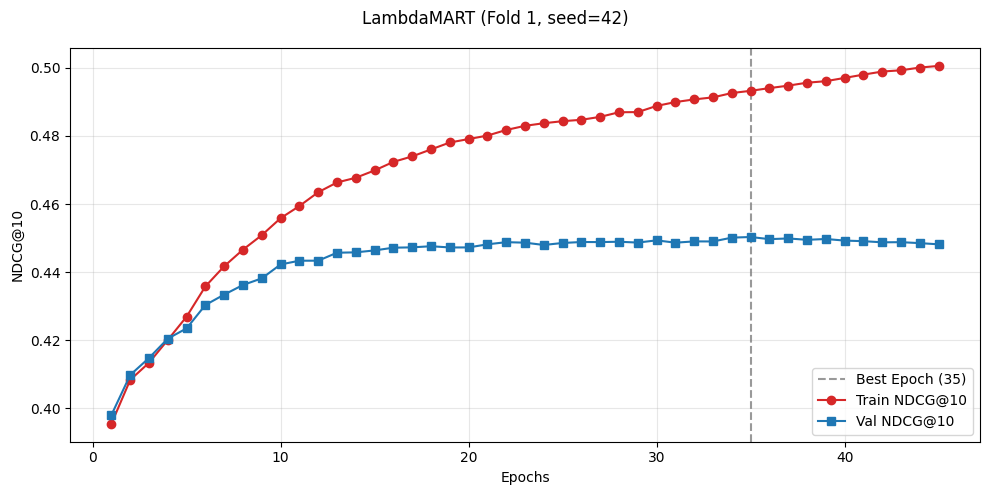

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (Fold 1, seed=42)")


## Key Takeaways:
- The model is overfitting. To reduce overfitting we can change the following hyperparameters.
  1. Reduce Learning Rate - more number of trees - increases smoothlyy - Reduces Overfitting.
  2. Increase min_samples_leaf or Decrease Max_depth - This will reduce the complexity of each tree.

## Next Steps:
- First i would like to try changing learning rate.

In [7]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.4322
  NDCG@3  : 0.4208
  NDCG@5  : 0.4277
  NDCG@10 : 0.4421


## Key Takeaways:
- The result is same as LambdaRank but it should perform better tham lambdaRank let us see by fien tuning the lambdaMart.

# Learning Rate = 0.1

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.1000 | η·α*: 0.0100 | Train NDCG@10: 0.3954 | Val NDCG@10: 0.3980  <- best
Tree 002 | α*: 0.0091 | η·α*: 0.0009 | Train NDCG@10: 0.4031 | Val NDCG@10: 0.4045  <- best
Tree 003 | α*: 0.0066 | η·α*: 0.0007 | Train NDCG@10: 0.4047 | Val NDCG@10: 0.4057  <- best
Tree 004 | α*: 0.0056 | η·α*: 0.0006 | Train NDCG@10: 0.4057 | Val NDCG@10: 0.4067  <- best
Tree 005 | α*: 0.0092 | η·α*: 0.0009 | Train NDCG@10: 0.4070 | Val NDCG@10: 0.4077  <- best
Tree 006 | α*: 0.0033 | η·α*: 0.0003 | Train NDCG@10: 0.4071 | Val NDCG@10: 0.4083  <- best
Tree 007 | α*: 0.0082 | η·α*: 0.0008 | Train NDCG@10: 0.4077 | Val NDCG@10: 0.4085  <- best
Tree 008 | α*: 0.0065 | η·α*: 0.0006 | Train NDCG@10: 0.4086 | Val NDCG@10: 0.4094  <- best
Tree 009 | α*: 0.0059 | η·α*: 0.0006 | Train NDCG@10: 0.4091 | Val NDCG@10: 0.4099  <- best
Tree 010 | α*: 0.0053 | η·α*: 0.0005 | Train NDCG@10: 0.4092 | Val NDCG@10: 0.4105  <- best
Tree 011 | α*: 0.0038 | η·α*: 0.0004 | Train NDCG@10: 0.4094 | Val NDCG@10: 0.41

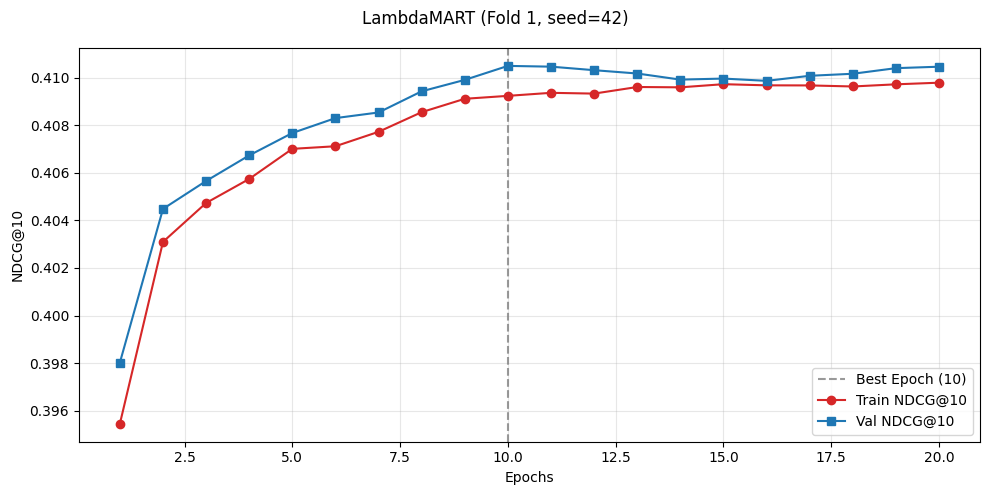

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (Fold 1, seed=42)")


## Key Takeaways:
- Overfitting is reduced but both the curves flattend out early this is underfitting. Let us increase lr.

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3928
  NDCG@3  : 0.3805
  NDCG@5  : 0.3852
  NDCG@10 : 0.4019


- Result is worse

# Learning Rate = 0.25

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.25,
    max_depth=6,
    min_samples_leaf=20,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.2500 | η·α*: 0.0625 | Train NDCG@10: 0.3954 | Val NDCG@10: 0.3980  <- best
Tree 002 | α*: 0.0949 | η·α*: 0.0237 | Train NDCG@10: 0.4054 | Val NDCG@10: 0.4061  <- best
Tree 003 | α*: 0.0578 | η·α*: 0.0144 | Train NDCG@10: 0.4078 | Val NDCG@10: 0.4088  <- best
Tree 004 | α*: 0.0434 | η·α*: 0.0109 | Train NDCG@10: 0.4088 | Val NDCG@10: 0.4104  <- best
Tree 005 | α*: 0.0345 | η·α*: 0.0086 | Train NDCG@10: 0.4090 | Val NDCG@10: 0.4105  <- best
Tree 006 | α*: 0.0367 | η·α*: 0.0092 | Train NDCG@10: 0.4094 | Val NDCG@10: 0.4103
Tree 007 | α*: 0.0283 | η·α*: 0.0071 | Train NDCG@10: 0.4098 | Val NDCG@10: 0.4103
Tree 008 | α*: 0.0031 | η·α*: 0.0008 | Train NDCG@10: 0.4098 | Val NDCG@10: 0.4104
Tree 009 | α*: 0.0756 | η·α*: 0.0189 | Train NDCG@10: 0.4102 | Val NDCG@10: 0.4102
Tree 010 | α*: 0.0015 | η·α*: 0.0004 | Train NDCG@10: 0.4102 | Val NDCG@10: 0.4102
Tree 011 | α*: 0.0016 | η·α*: 0.0004 | Train NDCG@10: 0.4102 | Val NDCG@10: 0.4103
Tree 012 | α*: 0.0012 | η·α*: 0.0003 | Tra

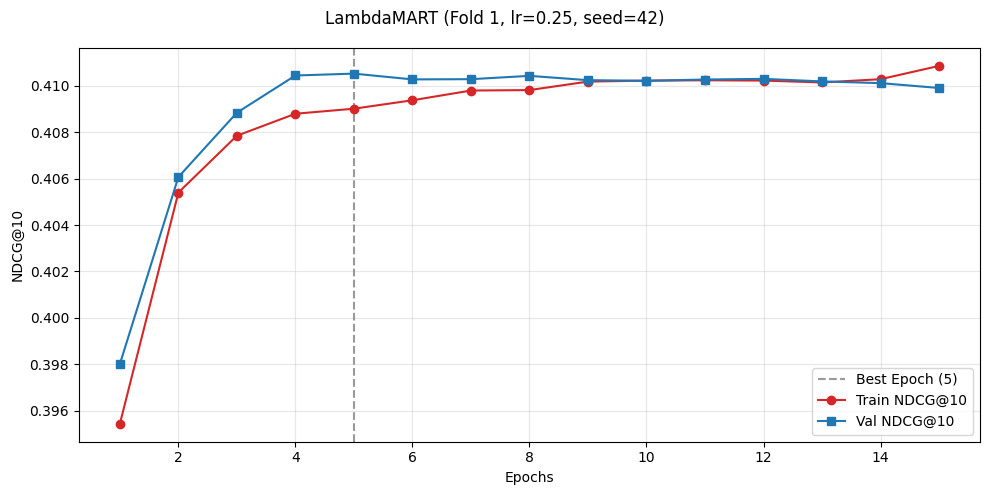

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (Fold 1, lr=0.25, seed=42)")


### Still the same problem

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3987
  NDCG@3  : 0.3808
  NDCG@5  : 0.3858
  NDCG@10 : 0.4023


## Key Takeaways:
- The problem still persists.

## Next Steps:
- First I would like to fine-tune tree complexity then i will find the best possible Learning Rate for that tree complexity.

## Step 7 · Optimizing the tree complexity(Max_depth and Min_samples_leaf)

- Using grid search to find best pair of max_depth and min_samples_leaf.

In [ ]:
import itertools
import pandas as pd

# Fixed at a middle learning rate for this pass (tuning depth/leaf as a pair first)
FIXED_LR = 0.5

max_depth_grid = [6]
min_samples_leaf_grid = [20, 50, 100]

results = []

for max_depth, min_samples_leaf in itertools.product(max_depth_grid, min_samples_leaf_grid):
    set_seed(42)

    model = LambdaMART(
        n_estimators=100,
        learning_rate=FIXED_LR,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        k=10,
        patience=10,
        use_optimal_line_search=True
    )

    best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        verbose=False
    )

    test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

    row = {
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "learning_rate": FIXED_LR,
    }
    for k in K_LIST:
        row[f"NDCG@{k}"] = test_ndcg[k]
    results.append(row)

    print(f"max_depth={max_depth:<2} | min_samples_leaf={min_samples_leaf:<4} | "
          + " | ".join(f"NDCG@{k}: {test_ndcg[k]:.4f}" for k in K_LIST))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=f"NDCG@10", ascending=False).reset_index(drop=True)

print("\nRanked by NDCG@10:")
print(results_df.to_string(index=False))

max_depth=6  | min_samples_leaf=20   | NDCG@1: 0.4215 | NDCG@3: 0.4150 | NDCG@5: 0.4199 | NDCG@10: 0.4351
max_depth=6  | min_samples_leaf=50   | NDCG@1: 0.4299 | NDCG@3: 0.4157 | NDCG@5: 0.4200 | NDCG@10: 0.4358
max_depth=6  | min_samples_leaf=100  | NDCG@1: 0.4406 | NDCG@3: 0.4204 | NDCG@5: 0.4261 | NDCG@10: 0.4404

Ranked by NDCG@10:
 max_depth  min_samples_leaf  learning_rate   NDCG@1   NDCG@3   NDCG@5  NDCG@10
         6               100            0.5 0.440614 0.420370 0.426075 0.440403
         6                50            0.5 0.429857 0.415737 0.420002 0.435840
         6                20            0.5 0.421543 0.415004 0.419875 0.435109


## Key Takeaways:
- As the minimum number of samples in leaf is increased NDCG is also increased because if it is low the tree will become complex and memorizes the training data which fails in capturing the general pattern and give worse results.
- I will try changing the Max_depth now. First I will try using 100 minimum no.of samples if it underfits then i will reduce the number.

## Max_depth = 5, Min_samples_leaf = 100

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=5,
    min_samples_leaf=100,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3882 | Val NDCG@10: 0.3938  <- best
Tree 002 | α*: 0.2749 | η·α*: 0.1375 | Train NDCG@10: 0.3987 | Val NDCG@10: 0.4019  <- best
Tree 003 | α*: 0.3371 | η·α*: 0.1685 | Train NDCG@10: 0.4031 | Val NDCG@10: 0.4049  <- best
Tree 004 | α*: 2.0496 | η·α*: 1.0248 | Train NDCG@10: 0.4082 | Val NDCG@10: 0.4100  <- best
Tree 005 | α*: 0.9408 | η·α*: 0.4704 | Train NDCG@10: 0.4159 | Val NDCG@10: 0.4160  <- best
Tree 006 | α*: 1.2942 | η·α*: 0.6471 | Train NDCG@10: 0.4276 | Val NDCG@10: 0.4257  <- best
Tree 007 | α*: 0.9574 | η·α*: 0.4787 | Train NDCG@10: 0.4337 | Val NDCG@10: 0.4272  <- best
Tree 008 | α*: 0.6805 | η·α*: 0.3403 | Train NDCG@10: 0.4387 | Val NDCG@10: 0.4307  <- best
Tree 009 | α*: 0.8627 | η·α*: 0.4313 | Train NDCG@10: 0.4416 | Val NDCG@10: 0.4330  <- best
Tree 010 | α*: 1.2024 | η·α*: 0.6012 | Train NDCG@10: 0.4447 | Val NDCG@10: 0.4330
Tree 011 | α*: 0.7779 | η·α*: 0.3889 | Train NDCG@10: 0.4475 | Val NDCG@10: 0.4348  <- be

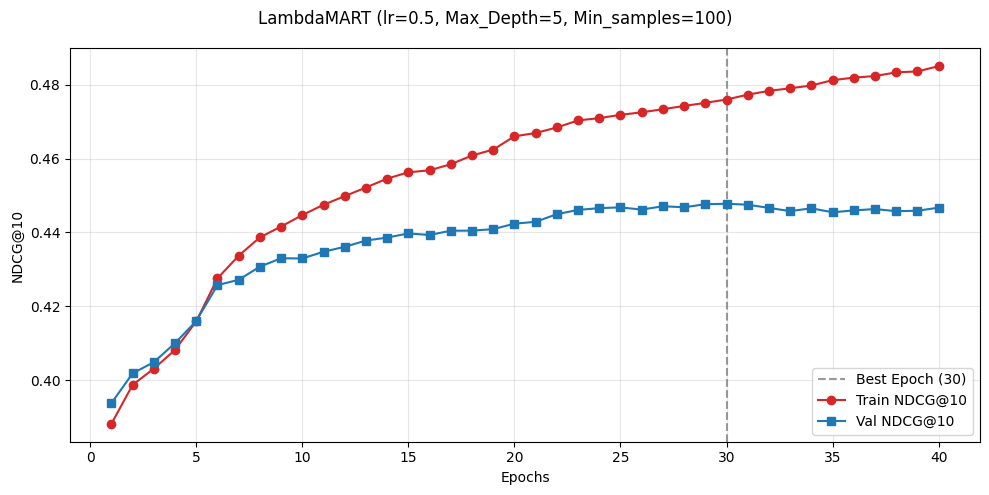

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=5, Min_samples=100)")


## Key Takeaways:
- The model is still overfitting. If we reduce the `min_samples_leaf` it will just overfit more. So, i will just try reducing the max_depth.

## Results on Test data

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=100)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — (lr=0.5, Max_Depth=5, Min_samples=100)
──────────────────────────────
  NDCG@1  : 0.4278
  NDCG@3  : 0.4142
  NDCG@5  : 0.4178
  NDCG@10 : 0.4350


## Max_depth = 4, Min_samples_leaf = 100

In [ ]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=4,
    min_samples_leaf=100,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3737 | Val NDCG@10: 0.3771  <- best
Tree 002 | α*: 0.1634 | η·α*: 0.0817 | Train NDCG@10: 0.3923 | Val NDCG@10: 0.3987  <- best
Tree 003 | α*: 0.3578 | η·α*: 0.1789 | Train NDCG@10: 0.3950 | Val NDCG@10: 0.3998  <- best
Tree 004 | α*: 0.2964 | η·α*: 0.1482 | Train NDCG@10: 0.3968 | Val NDCG@10: 0.4021  <- best
Tree 005 | α*: 0.9972 | η·α*: 0.4986 | Train NDCG@10: 0.4020 | Val NDCG@10: 0.4062  <- best
Tree 006 | α*: 1.0678 | η·α*: 0.5339 | Train NDCG@10: 0.4103 | Val NDCG@10: 0.4142  <- best
Tree 007 | α*: 0.9432 | η·α*: 0.4716 | Train NDCG@10: 0.4205 | Val NDCG@10: 0.4225  <- best
Tree 008 | α*: 1.0837 | η·α*: 0.5419 | Train NDCG@10: 0.4280 | Val NDCG@10: 0.4267  <- best
Tree 009 | α*: 1.0233 | η·α*: 0.5116 | Train NDCG@10: 0.4328 | Val NDCG@10: 0.4326  <- best
Tree 010 | α*: 0.8609 | η·α*: 0.4304 | Train NDCG@10: 0.4363 | Val NDCG@10: 0.4343  <- best
Tree 011 | α*: 1.0482 | η·α*: 0.5241 | Train NDCG@10: 0.4384 | Val NDCG@10: 0.43

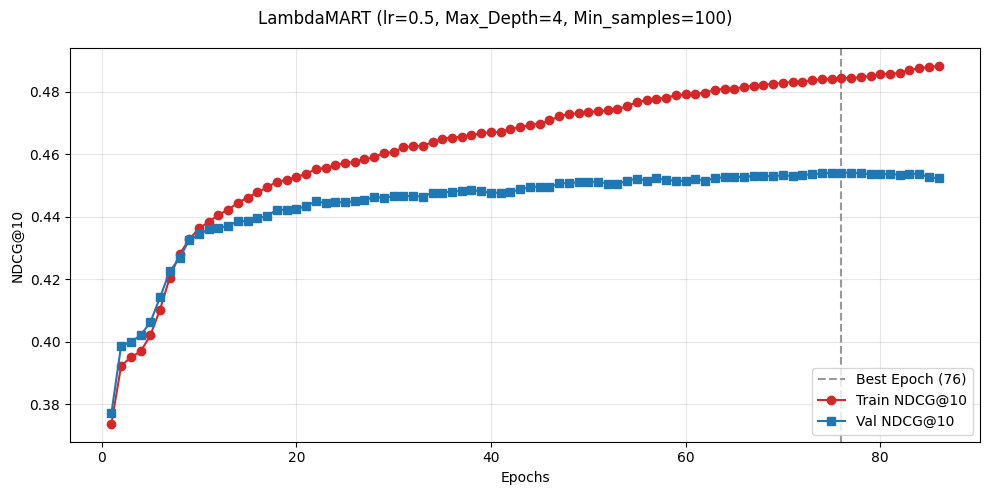

In [ ]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=4, Min_samples=100)")


## Key Takeaways:
- The model is still overfitting. No need to reduce the `min_samples_leaf`.
- Reducing `Max_depth` is also not good i think as depth=4 is very less.
- We should keep increasing `min_samples_leaf`

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=4, Min_samples=100)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — (lr=0.5, Max_Depth=4, Min_samples=100)
──────────────────────────────
  NDCG@1  : 0.4303
  NDCG@3  : 0.4205
  NDCG@5  : 0.4254
  NDCG@10 : 0.4418


## Key Takeaways:
- As we reduce the `Max_depth` the result is getting better. So, reducing max_depth helping to regularize the model.

# Important Findings:
- Current `min_samples_leaf = 100`, there are 120*6000 = 720000 documents.
- Current `max_depth = 4`, Maximum possible leaves = 16. Documents in one leaf = ~45000. Therefore, `min_samples_leaf=100` is not even a good constraint. It will just split even though a node have some 1000 documents. This is not good.

## Next Steps:
- Use very large `min_samples_leaf` value and since there are large number of documents i will try increasing max_depth and find the best pair of `max_depth` and `min_samples_leaf` to find the best tree complexity.
- Then optimize Learning rate.

## Max_depth = 6, Min_samples_leaf = 2500

In [8]:
set_seed(42)

model = LambdaMART(
    n_estimators=100,
    learning_rate=0.5,
    max_depth=6,
    min_samples_leaf=2500,
    k=10,
    patience=10,
    use_optimal_line_search=True
)

best_model, last_model, train_ndcg_history, val_ndcg_history = model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

Tree 001 | α*: 0.5000 | η·α*: 0.2500 | Train NDCG@10: 0.3935 | Val NDCG@10: 0.3977  <- best
Tree 002 | α*: 0.2703 | η·α*: 0.1351 | Train NDCG@10: 0.4052 | Val NDCG@10: 0.4093  <- best
Tree 003 | α*: 0.5367 | η·α*: 0.2683 | Train NDCG@10: 0.4120 | Val NDCG@10: 0.4157  <- best
Tree 004 | α*: 0.6725 | η·α*: 0.3363 | Train NDCG@10: 0.4207 | Val NDCG@10: 0.4224  <- best
Tree 005 | α*: 0.7474 | η·α*: 0.3737 | Train NDCG@10: 0.4277 | Val NDCG@10: 0.4304  <- best
Tree 006 | α*: 0.9718 | η·α*: 0.4859 | Train NDCG@10: 0.4351 | Val NDCG@10: 0.4366  <- best
Tree 007 | α*: 0.7270 | η·α*: 0.3635 | Train NDCG@10: 0.4400 | Val NDCG@10: 0.4402  <- best
Tree 008 | α*: 0.8526 | η·α*: 0.4263 | Train NDCG@10: 0.4444 | Val NDCG@10: 0.4417  <- best
Tree 009 | α*: 0.7930 | η·α*: 0.3965 | Train NDCG@10: 0.4480 | Val NDCG@10: 0.4439  <- best
Tree 010 | α*: 0.8060 | η·α*: 0.4030 | Train NDCG@10: 0.4519 | Val NDCG@10: 0.4457  <- best
Tree 011 | α*: 0.9094 | η·α*: 0.4547 | Train NDCG@10: 0.4545 | Val NDCG@10: 0.44

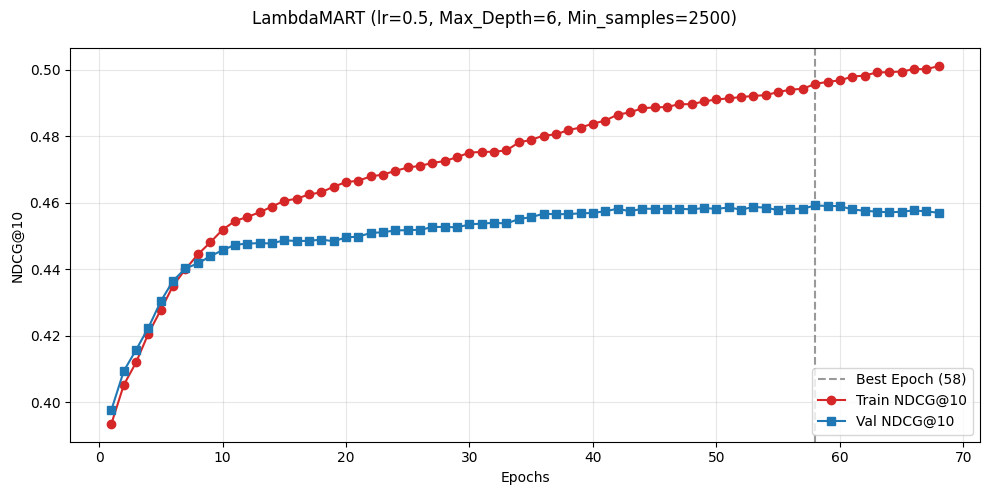

In [9]:
plot_training_curves(train_ndcg_history,val_ndcg_history, "LambdaMART (lr=0.5, Max_Depth=6, Min_samples=2500)")

## Key Takeaways:
- The model performed so better than the previous ones. But the overfitting problem still persists. So, I will increase the `min_samples_leaf` furhter.

In [10]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=2500)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")


Test Set NDCG — (lr=0.5, Max_Depth=6, Min_samples=2500)
──────────────────────────────
  NDCG@1  : 0.4332
  NDCG@3  : 0.4296
  NDCG@5  : 0.4326
  NDCG@10 : 0.4470


## Key Takeaways:
- The Result is close the intial ones and a bit better. If I control ovefitting I can get better results.